## Introducción teórica

La densidad espectral de potencia permite analizar cómo se distribuye la potencia de una señal en función de la frecuencia y caracterizar estadísticamente el contenido espectral de señales que pueden presentar ruido.

En este trabajo se estima la densidad espectral de tres señales mediante tres métodos. Para la señal de audio correspondiente a un silbido se utiliza el método de **Blackman-Tukey**.

El método de Blackman-Tukey según el cual la densidad espectral de potencia de una señal puede obtenerse como la transformada de Fourier de su función de autocorrelación:

$$
S_{xx}(f)=\mathcal{F}\{R_{xx}(\tau)\}
$$

Para una señal discreta \(x[n]\), se estima primero la autocorrelación:

$$
\hat{R}_{xx}[k]
$$

 La autocorrelación permite determinar cuánto se parece la señal a sí misma al desplazarla un determinado número de muestras. En señales aproximadamente periódicas, como un silbido, esta función presenta una estructura periódica relacionada con la frecuencia fundamental de la señal.

En el método de Blackman-Tukey no se utiliza toda la estimación de autocorrelación. Se selecciona un intervalo de retardos y se aplica una ventana a dicha estimación. En este trabajo se utiliza una ventana Blackman:

$$
w[k]
$$

obteniéndose una autocorrelación ventaneada:

$$
\hat{R}_{xx,w}[k]
=
\hat{R}_{xx}[k]\,w[k]
$$



Por ultimo, la densidad espectral de potencia se obtiene calculando la transformada de Fourier de la autocorrelación ventaneada:



De esta manera, el procedimiento seguido para el análisis del silbido puede resumirse como:

$$
x[n]
\longrightarrow
\hat{R}_{xx}[k]
\longrightarrow
\hat{R}_{xx}[k]w[k]
\longrightarrow
\mathcal{F}\{\cdot\}
\longrightarrow
\hat{S}_{xx}(f)
$$

La PSD obtenida permite identificar las componentes frecuenciales predominantes del silbido y analizar su contenido espectral.


PPG con Welch

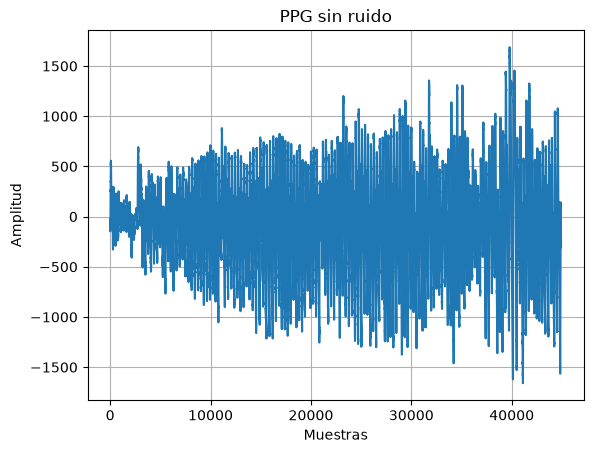

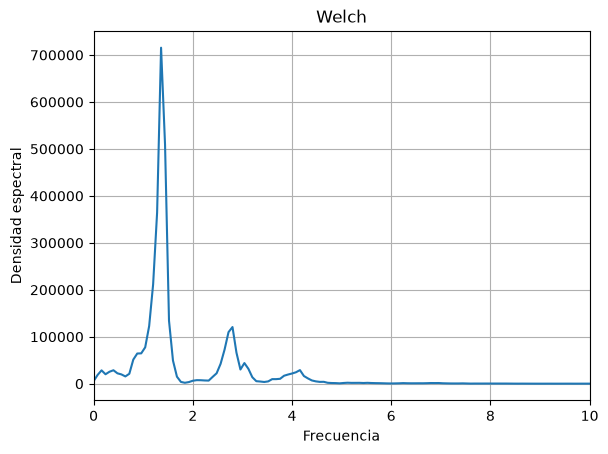

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Thu Sep 17 21:20:16 2026

@author: 
"""

import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io.wavfile import write


#%% PPG

fs_ppg = 400  # Frecuencia de muestreo [Hz]


# PPG sin ruido
ppg_sin_ruido = np.load('ppg_sin_ruido.npy')


#%% Señal PPG sin ruido

plt.figure()
plt.plot(ppg_sin_ruido)
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.title('PPG sin ruido')
plt.grid()
plt.show()


#%% PSD mediante método de Welch

f, Pxx = sig.welch(ppg_sin_ruido,fs=fs_ppg, nperseg = 5000)

plt.figure()
plt.plot(f, Pxx)
plt.xlim(0, 10)
plt.xlabel('Frecuencia')
plt.ylabel('Densidad espectral')
plt.title('Welch')
plt.grid()
plt.show()


